# EXP031: Oracle MFIとの選択項目Fisher情報量差

Bank 1について、Oracle MFI、通常MFI、固定epsilon版DQNの各gammaが各stepで選んだ項目のFisher情報量を、同じ受検者の真のthetaで再計算します。

各受検者 $i$、step $t$、手法 $m$ の符号付き差と絶対差を次のように定義します。

$$
d_{i,t,m}=I_{a^{\mathrm{oracle}}_{i,t}}(\theta_{i,\mathrm{true}})-I_{a^m_{i,t}}(\theta_{i,\mathrm{true}}),
\qquad |d_{i,t,m}|.
$$

手法ごとに既出項目が異なるため、符号付き差は負になる場合があります。Oracle MFIへの近さは主に平均絶対差で評価します。さらに、各DQNについて `DQNの絶対差 - MFIの絶対差` を計算します。この値が負なら、その受検者・stepではDQNの方が通常MFIよりOracle MFIに近いFIの項目を選んでいます。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root():
    candidates = []
    if "__file__" in globals():
        script_dir = Path(__file__).resolve().parent
        candidates.extend([script_dir, *script_dir.parents])

    cwd = Path.cwd().resolve()
    candidates.extend(
        [
            cwd,
            *cwd.parents,
            cwd / "Grad_Research",
            cwd
            / "Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History",
            Path("/content/Grad_Research"),
            Path(
                "/content/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History"
            ),
            Path("/content/drive/MyDrive/Grad_Research"),
            Path(
                "/content/drive/MyDrive/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History"
            ),
        ]
    )

    for root in candidates:
        if (root / "data").is_dir() and (root / "EXP031").is_dir():
            return root

    raise FileNotFoundError("Could not find the project root.")


ROOT = find_project_root()
RESULTS_DIR = ROOT / "EXP031" / "results"
BANK_TYPE = "uncor"
BANK_ID = 1
DQN_GAMMAS = (0, 0.1, 0.3, 0.6, 0.9)
KEY_STEPS = (1, 5, 10, 20, 30, 40)
KEY_COLUMNS = ["userID", "step"]
TIE_TOLERANCE = 1e-12

print(f"Project root: {ROOT}")
print(f"Results dir : {RESULTS_DIR}")
print(f"Bank        : {BANK_TYPE} {BANK_ID}")
print(f"DQN gammas  : {DQN_GAMMAS}")

Project root: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
Results dir : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results
Bank        : uncor 1
DQN gammas  : (0, 0.1, 0.3, 0.6, 0.9)


In [2]:
def gamma_token(gamma):
    return str(gamma)


def read_records(path, require_theta_true=False):
    if not path.is_file():
        raise FileNotFoundError(f"Missing records file: {path}")

    frame = pd.read_csv(path)
    required = {"userID", "step", "itemID"}
    if require_theta_true:
        required.add("theta_true")
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")

    numeric_columns = list(required)
    for column in numeric_columns:
        frame[column] = pd.to_numeric(frame[column], errors="raise")
        if not np.isfinite(frame[column]).all():
            raise ValueError(f"{path.name}: {column} contains non-finite values.")

    for column in ["userID", "step", "itemID"]:
        if not np.allclose(frame[column], np.round(frame[column])):
            raise ValueError(f"{path.name}: {column} must contain integer values.")
        frame[column] = frame[column].astype(np.int64)

    if frame.duplicated(KEY_COLUMNS).any():
        raise ValueError(f"{path.name} has duplicate userID-step rows.")

    return frame.sort_values(KEY_COLUMNS).reset_index(drop=True)


def assert_same_keys(reference, candidate, label):
    if not reference[KEY_COLUMNS].equals(candidate[KEY_COLUMNS]):
        raise ValueError(
            f"{label} does not have the same userID-step rows as Oracle MFI."
        )


def fisher_information_for_rows(item_bank, item_ids, theta, D=1.0):
    if np.any(item_ids < 1) or np.any(item_ids > len(item_bank)):
        raise ValueError("itemID is outside the item-bank range.")

    item_parameters = item_bank[item_ids - 1]
    a = item_parameters[:, 0]
    b = item_parameters[:, 1]
    c = item_parameters[:, 2]
    return (
        D**2
        * a**2
        * (1 - c)
        / (c + np.exp(D * a * (theta - b)))
        / (1 + np.exp(-D * a * (theta - b))) ** 2
    )


def mean_ci95(values):
    values = np.asarray(values, dtype=float)
    mean = float(np.mean(values))
    if len(values) < 2:
        return mean, np.nan, np.nan
    half_width = 1.96 * float(np.std(values, ddof=1)) / np.sqrt(len(values))
    return mean, mean - half_width, mean + half_width

In [3]:
item_bank_path = (
    ROOT / "data" / "uncorrelated_banks" / f"item_bank_{BANK_TYPE}_{BANK_ID}.csv"
)
item_bank_frame = pd.read_csv(item_bank_path)
item_bank = item_bank_frame[["a", "b", "c"]].to_numpy(dtype=float)

oracle_path = RESULTS_DIR / f"records_{BANK_TYPE}_{BANK_ID}_MFI_oracle_MLE_python.csv"
mfi_path = RESULTS_DIR / f"records_{BANK_TYPE}_{BANK_ID}_MFI_MLE_python.csv"
dqn_paths = {
    gamma: RESULTS_DIR
    / f"records_{BANK_TYPE}_{BANK_ID}_DQN_MLE_gamma_{gamma_token(gamma)}.csv"
    for gamma in DQN_GAMMAS
}

oracle_records = read_records(oracle_path, require_theta_true=True)
mfi_records = read_records(mfi_path, require_theta_true=True)
dqn_records = {gamma: read_records(path) for gamma, path in dqn_paths.items()}

assert_same_keys(oracle_records, mfi_records, "MFI")
if not np.allclose(
    oracle_records["theta_true"],
    mfi_records["theta_true"],
    rtol=0.0,
    atol=1e-12,
):
    raise ValueError("MFI and Oracle MFI theta_true values differ.")

for gamma, frame in dqn_records.items():
    label = f"DQN gamma={gamma}"
    assert_same_keys(oracle_records, frame, label)
    if {"theta_est", "bias"}.issubset(frame.columns):
        reconstructed_theta = frame["theta_est"] - frame["bias"]
        if not np.allclose(
            reconstructed_theta,
            oracle_records["theta_true"],
            rtol=0.0,
            atol=1e-10,
        ):
            raise ValueError(f"{label} does not use the same test theta values.")

print(f"Item bank rows : {len(item_bank):,}")
print(f"Examinees      : {oracle_records['userID'].nunique():,}")
print(f"Test steps     : {oracle_records['step'].nunique():,}")
print(f"Record rows    : {len(oracle_records):,}")
print(f"Oracle records : {oracle_path.name}")
print(f"MFI records    : {mfi_path.name}")
for gamma, path in dqn_paths.items():
    print(f"DQN gamma={gamma}: {path.name}")

Item bank rows : 500
Examinees      : 5,000
Test steps     : 40
Record rows    : 200,000
Oracle records : records_uncor_1_MFI_oracle_MLE_python.csv
MFI records    : records_uncor_1_MFI_MLE_python.csv
DQN gamma=0: records_uncor_1_DQN_MLE_gamma_0.csv
DQN gamma=0.1: records_uncor_1_DQN_MLE_gamma_0.1.csv
DQN gamma=0.3: records_uncor_1_DQN_MLE_gamma_0.3.csv
DQN gamma=0.6: records_uncor_1_DQN_MLE_gamma_0.6.csv
DQN gamma=0.9: records_uncor_1_DQN_MLE_gamma_0.9.csv


In [4]:
theta_true = oracle_records["theta_true"].to_numpy(dtype=float)
oracle_item_ids = oracle_records["itemID"].to_numpy(dtype=np.int64)
oracle_fi = fisher_information_for_rows(item_bank, oracle_item_ids, theta_true)

method_records = {"MFI": mfi_records}
method_records.update(
    {f"DQN (gamma={gamma})": frame for gamma, frame in dqn_records.items()}
)
METHOD_ORDER = list(method_records)

comparison_frames = []
for method, frame in method_records.items():
    selected_item_ids = frame["itemID"].to_numpy(dtype=np.int64)
    selected_fi = fisher_information_for_rows(item_bank, selected_item_ids, theta_true)
    signed_diff = oracle_fi - selected_fi
    comparison_frames.append(
        pd.DataFrame(
            {
                "userID": oracle_records["userID"],
                "step": oracle_records["step"],
                "method": method,
                "theta_true": theta_true,
                "oracle_itemID": oracle_item_ids,
                "selected_itemID": selected_item_ids,
                "oracle_item_fi": oracle_fi,
                "selected_item_fi": selected_fi,
                "signed_fi_diff": signed_diff,
                "absolute_fi_diff": np.abs(signed_diff),
                "same_item_as_oracle": selected_item_ids == oracle_item_ids,
            }
        )
    )

comparison = pd.concat(comparison_frames, ignore_index=True)
print(f"Comparison rows: {len(comparison):,}")
display(comparison.head())

Comparison rows: 1,200,000


,userID,step,method,theta_true,oracle_itemID,selected_itemID,oracle_item_fi,selected_item_fi,signed_fi_diff,absolute_fi_diff,same_item_as_oracle
0,1,1,MFI,1.041073,10,55,0.502189,0.233351,0.268837,0.268837,False
1,1,2,MFI,1.041073,424,424,0.449605,0.449605,0.000000,0.000000,True
2,1,3,MFI,1.041073,383,406,0.431251,0.267151,0.164099,0.164099,False
3,1,4,MFI,1.041073,47,10,0.403587,0.502189,-0.098602,0.098602,False
4,1,5,MFI,1.041073,24,33,0.398759,0.179723,0.219036,0.219036,False


In [5]:
summary_rows = []
for (step, method), group in comparison.groupby(["step", "method"], sort=False):
    signed_mean, signed_ci_low, signed_ci_high = mean_ci95(group["signed_fi_diff"])
    absolute_mean, absolute_ci_low, absolute_ci_high = mean_ci95(
        group["absolute_fi_diff"]
    )
    summary_rows.append(
        {
            "step": int(step),
            "method": method,
            "n_examinees": len(group),
            "mean_oracle_item_fi": group["oracle_item_fi"].mean(),
            "mean_selected_item_fi": group["selected_item_fi"].mean(),
            "mean_signed_fi_diff": signed_mean,
            "signed_fi_diff_ci95_low": signed_ci_low,
            "signed_fi_diff_ci95_high": signed_ci_high,
            "mean_absolute_fi_diff": absolute_mean,
            "absolute_fi_diff_ci95_low": absolute_ci_low,
            "absolute_fi_diff_ci95_high": absolute_ci_high,
            "median_absolute_fi_diff": group["absolute_fi_diff"].median(),
            "rmse_fi_diff": np.sqrt(np.mean(group["signed_fi_diff"] ** 2)),
            "same_item_rate": group["same_item_as_oracle"].mean(),
        }
    )

fi_diff_summary = pd.DataFrame(summary_rows)
method_rank = {method: rank for rank, method in enumerate(METHOD_ORDER)}
fi_diff_summary["method_rank"] = fi_diff_summary["method"].map(method_rank)
fi_diff_summary = (
    fi_diff_summary.sort_values(["step", "method_rank"])
    .drop(columns="method_rank")
    .reset_index(drop=True)
)

summary_path = (
    RESULTS_DIR / f"selected_item_fi_diff_vs_oracle_{BANK_TYPE}_{BANK_ID}.csv"
)
fi_diff_summary.to_csv(summary_path, index=False)
print(f"Saved summary: {summary_path}")
display(fi_diff_summary.head(len(METHOD_ORDER)))

Saved summary: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/selected_item_fi_diff_vs_oracle_uncor_1.csv


,step,method,n_examinees,mean_oracle_item_fi,mean_selected_item_fi,mean_signed_fi_diff,signed_fi_diff_ci95_low,signed_fi_diff_ci95_high,mean_absolute_fi_diff,absolute_fi_diff_ci95_low,absolute_fi_diff_ci95_high,median_absolute_fi_diff,rmse_fi_diff,same_item_rate
0,1,MFI,5000,0.477319,0.327196,0.150123,0.146308,0.153938,0.150123,0.146308,0.153938,0.102309,0.203651,0.2632
1,1,DQN (gamma=0),5000,0.477319,0.308202,0.169117,0.165649,0.172584,0.169117,0.165649,0.172584,0.150710,0.210349,0.1326
2,1,DQN (gamma=0.1),5000,0.477319,0.268759,0.208559,0.204872,0.212246,0.208559,0.204872,0.212246,0.208884,0.247361,0.0718
3,1,DQN (gamma=0.3),5000,0.477319,0.307485,0.169834,0.166445,0.173222,0.169834,0.166445,0.173222,0.151132,0.209244,0.1350
4,1,DQN (gamma=0.6),5000,0.477319,0.314708,0.162610,0.159062,0.166159,0.162610,0.159062,0.166159,0.129706,0.206953,0.1542
5,1,DQN (gamma=0.9),5000,0.477319,0.272828,0.204490,0.201455,0.207526,0.204490,0.201455,0.207526,0.210625,0.231964,0.0564


Saved figure: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/selected_item_fi_diff_vs_oracle_uncor_1.png


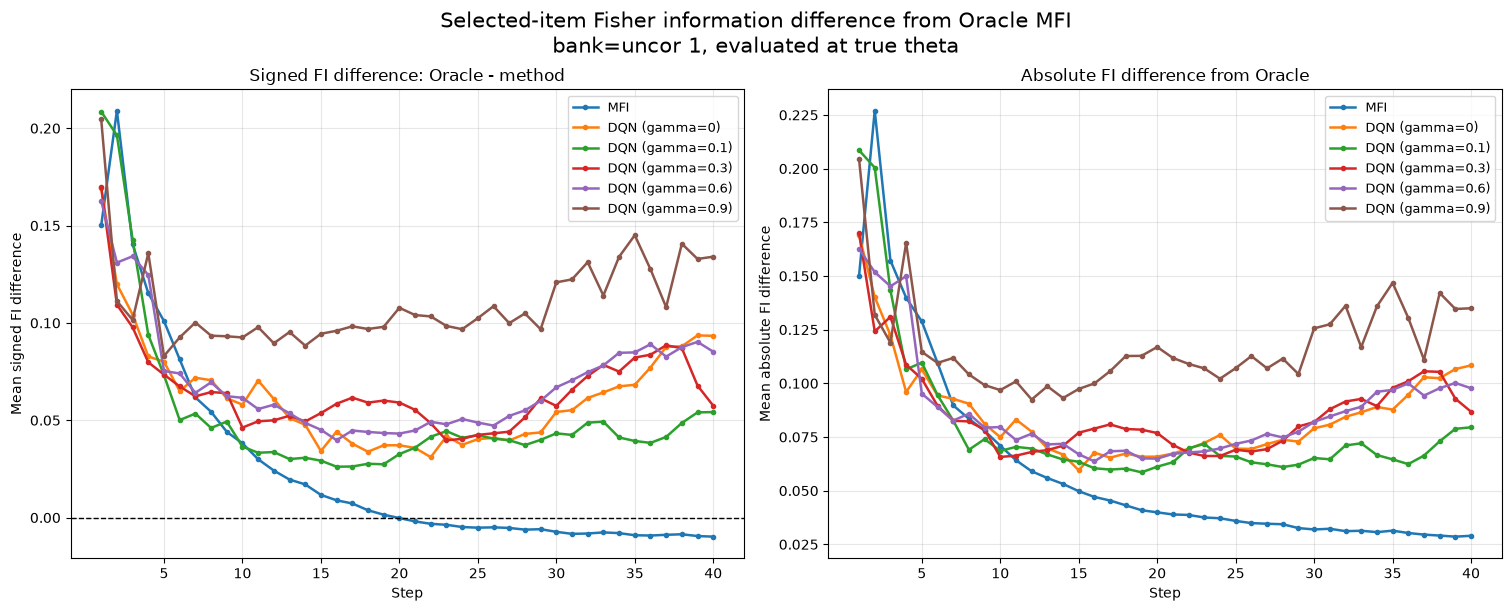

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

for method in METHOD_ORDER:
    curve = fi_diff_summary[fi_diff_summary["method"] == method]
    axes[0].plot(
        curve["step"],
        curve["mean_signed_fi_diff"],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=method,
    )
    axes[1].plot(
        curve["step"],
        curve["mean_absolute_fi_diff"],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=method,
    )

axes[0].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[0].set_title("Signed FI difference: Oracle - method")
axes[0].set_ylabel("Mean signed FI difference")
axes[1].set_title("Absolute FI difference from Oracle")
axes[1].set_ylabel("Mean absolute FI difference")
for axis in axes:
    axis.set_xlabel("Step")
    axis.set_xticks(np.arange(5, 41, 5))
    axis.grid(alpha=0.3)
    axis.legend(fontsize=9)

fig.suptitle(
    f"Selected-item Fisher information difference from Oracle MFI\n"
    f"bank={BANK_TYPE} {BANK_ID}, evaluated at true theta",
    fontsize=15,
)
figure_path = RESULTS_DIR / f"selected_item_fi_diff_vs_oracle_{BANK_TYPE}_{BANK_ID}.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
print(f"Saved figure: {figure_path}")
plt.show()

Saved DQN-vs-MFI comparison: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/dqn_vs_mfi_oracle_fi_closeness_uncor_1.csv
Saved DQN-vs-MFI figure: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/dqn_vs_mfi_oracle_fi_closeness_uncor_1.png


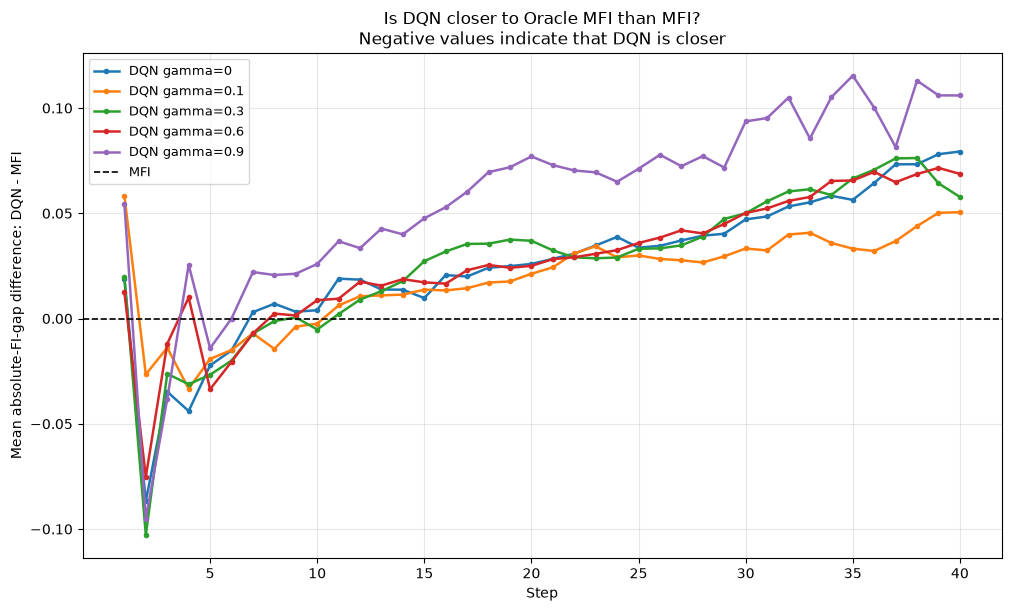

In [7]:
absolute_diff_wide = comparison.pivot(
    index=KEY_COLUMNS, columns="method", values="absolute_fi_diff"
).reset_index()

closeness_rows = []
for gamma in DQN_GAMMAS:
    method = f"DQN (gamma={gamma})"
    delta = absolute_diff_wide[method] - absolute_diff_wide["MFI"]
    working = pd.DataFrame(
        {
            "step": absolute_diff_wide["step"],
            "delta_absolute_fi_diff_vs_mfi": delta,
        }
    )
    for step, group in working.groupby("step"):
        values = group["delta_absolute_fi_diff_vs_mfi"].to_numpy()
        mean_delta, ci_low, ci_high = mean_ci95(values)
        closeness_rows.append(
            {
                "step": int(step),
                "gamma": gamma,
                "n_examinees": len(values),
                "mean_delta_absolute_fi_diff_vs_mfi": mean_delta,
                "mean_delta_ci95_low": ci_low,
                "mean_delta_ci95_high": ci_high,
                "proportion_dqn_closer_than_mfi": np.mean(values < -TIE_TOLERANCE),
                "proportion_tied": np.mean(np.abs(values) <= TIE_TOLERANCE),
                "proportion_dqn_farther_than_mfi": np.mean(values > TIE_TOLERANCE),
            }
        )

dqn_vs_mfi = pd.DataFrame(closeness_rows).sort_values(["step", "gamma"])
closeness_path = (
    RESULTS_DIR / f"dqn_vs_mfi_oracle_fi_closeness_{BANK_TYPE}_{BANK_ID}.csv"
)
dqn_vs_mfi.to_csv(closeness_path, index=False)
print(f"Saved DQN-vs-MFI comparison: {closeness_path}")

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for gamma in DQN_GAMMAS:
    curve = dqn_vs_mfi[dqn_vs_mfi["gamma"] == gamma]
    ax.plot(
        curve["step"],
        curve["mean_delta_absolute_fi_diff_vs_mfi"],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=f"DQN gamma={gamma}",
    )
ax.axhline(0.0, color="black", linewidth=1.2, linestyle="--", label="MFI")
ax.set_title(
    "Is DQN closer to Oracle MFI than MFI?\nNegative values indicate that DQN is closer"
)
ax.set_xlabel("Step")
ax.set_ylabel("Mean absolute-FI-gap difference: DQN - MFI")
ax.set_xticks(np.arange(5, 41, 5))
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
closeness_figure_path = (
    RESULTS_DIR / f"dqn_vs_mfi_oracle_fi_closeness_{BANK_TYPE}_{BANK_ID}.png"
)
fig.savefig(closeness_figure_path, dpi=200, bbox_inches="tight")
print(f"Saved DQN-vs-MFI figure: {closeness_figure_path}")
plt.show()

In [8]:
key_step_summary = fi_diff_summary[fi_diff_summary["step"].isin(KEY_STEPS)][
    [
        "step",
        "method",
        "mean_selected_item_fi",
        "mean_signed_fi_diff",
        "mean_absolute_fi_diff",
        "same_item_rate",
    ]
].copy()
key_step_path = (
    RESULTS_DIR / f"selected_item_fi_diff_vs_oracle_key_steps_{BANK_TYPE}_{BANK_ID}.csv"
)
key_step_summary.to_csv(key_step_path, index=False)

print(f"Saved key-step summary: {key_step_path}")
print("Mean absolute FI difference from Oracle MFI (smaller is closer):")
display(
    key_step_summary.pivot(
        index="method", columns="step", values="mean_absolute_fi_diff"
    ).loc[METHOD_ORDER]
)
print("DQN - MFI mean absolute-gap difference (negative means DQN is closer):")
display(
    dqn_vs_mfi[dqn_vs_mfi["step"].isin(KEY_STEPS)].pivot(
        index="gamma",
        columns="step",
        values="mean_delta_absolute_fi_diff_vs_mfi",
    )
)

Saved key-step summary: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP031/results/selected_item_fi_diff_vs_oracle_key_steps_uncor_1.csv
Mean absolute FI difference from Oracle MFI (smaller is closer):


step,1,5,10,20,30,40
method,,,,,,
MFI,0.150123,0.128806,0.070936,0.039907,0.031935,0.028986
DQN (gamma=0),0.169117,0.106529,0.074893,0.065850,0.079048,0.108338
DQN (gamma=0.1),0.208559,0.109644,0.068508,0.061180,0.065217,0.079517
DQN (gamma=0.3),0.169834,0.102100,0.065719,0.076855,0.081956,0.086760
DQN (gamma=0.6),0.162610,0.095199,0.079641,0.064923,0.082076,0.097705
DQN (gamma=0.9),0.204490,0.114658,0.096855,0.116917,0.125614,0.134963


DQN - MFI mean absolute-gap difference (negative means DQN is closer):


step,1,5,10,20,30,40
gamma,,,,,,
0.0,0.018994,-0.022277,0.003957,0.025943,0.047113,0.079352
0.1,0.058436,-0.019162,-0.002428,0.021273,0.033282,0.050531
0.3,0.019711,-0.026706,-0.005217,0.036948,0.050021,0.057775
0.6,0.012488,-0.033607,0.008705,0.025016,0.050141,0.068719
0.9,0.054367,-0.014148,0.025919,0.077010,0.093679,0.105978
